# 6. التدريب، الضبط والتقييم (Training, Tuning & Evaluation)

##  أهداف هذا الملف:
1. **الاعتماد على مقاييس غير متوازنة (Metrics Selection)**: توضيح لماذا الـ Accuracy مضلل، والتركيز على `ROC-AUC`, `PR-AUC (Average Precision)`, `F1-Score` للفئة 1 (الطلبات المتأخرة).
2. **بناء نموذج مرجعي (Baseline Model)**: البدء بموديل بسيط جداً لتحديد المستوى الأساسي للأداء.
3. **تدريب وضبط النماذج المتقدمة على الـ Validation Set**:
   - Logistic Regression (Unbalanced vs Balanced)
   - Random Forest (Balanced)
   - HistGradientBoosting / XGBoost (Balanced)
4. **حفظ الموديل الفائز والـ Artifacts**: حفظ `best_model.pkl` وملخص التقييمات `model_summary.csv`.
5. **التقييم لمرة واحدة على الـ Test Set (`test.csv`)**: لا يتم فتح أو استخدام بيانات الاختبار إلا في النهاية ولمرة واحدة فقط لتأكيد الأداء.


In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    average_precision_score, 
    f1_score, 
    recall_score, 
    precision_score, 
    roc_curve, 
    precision_recall_curve
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from IPython.display import display

has_xgb = False
try:
    import xgboost as xgb
    has_xgb = True
    print("✅ XGBoost is installed and ready!")
except ImportError:
    print("ℹ️ XGBoost not installed, HistGradientBoosting will be used.")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("✅ Libraries imported successfully!")


✅ XGBoost is installed and ready!
✅ Libraries imported successfully!


## 1️⃣ تحميل بيانات التدريب والـ Artifacts المحفوظة من notebook5


In [2]:
df_train = pd.read_csv("train_cleaned.csv")
train_cols = joblib.load("train_columns.pkl")
scaler = joblib.load("my_scaler.pkl")

X_train = df_train.drop(columns=["is_late"])
y_train = df_train["is_late"]

print(f"✅ X_train shape: {X_train.shape}")
print(f"✅ y_train shape: {y_train.shape}")
print("✅ Target (is_late) distribution in Train:")
print(y_train.value_counts(normalize=True))


✅ X_train shape: (65616, 84)
✅ y_train shape: (65616,)
✅ Target (is_late) distribution in Train:
is_late
0    0.920583
1    0.079417
Name: proportion, dtype: float64


## 2️⃣ دالة المعالجة والمطابقة لبيانات الـ Validation والـ Test


In [3]:
def preprocess_dataset(file_path, train_columns, fitted_scaler):
    """
    دالة تطبيق نفس pipeline الـ Preprocessing الموجود في notebook5
    مباشرة على بيانات الـ Validation أو الـ Test مع ضمان المطابقة 100%
    """
    df = pd.read_csv(file_path)
    
    date_cols = [
        "order_purchase_timestamp", "order_approved_at", 
        "order_delivered_carrier_date", "order_delivered_customer_date", 
        "order_estimated_delivery_date"
    ]
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
            
    columns_to_drop = [
        "order_id", "customer_id", "customer_unique_id", "review_id", 
        "review_comment_title", "review_comment_message", 
        "geolocation_zip_code_prefix", "customer_zip_code_prefix"
    ]
    df = df.drop(columns=[c for c in columns_to_drop if c in df.columns], errors="ignore")
    
    if "order_delivered_customer_date" in df.columns and "order_delivered_carrier_date" in df.columns:
        delivery_days = (df["order_delivered_customer_date"] - df["order_delivered_carrier_date"]).dt.days
        df = df[delivery_days >= 0]
        
    df["order_hour"] = df["order_purchase_timestamp"].dt.hour
    def get_time_of_day(hour):
        if 6 <= hour < 12: return "Morning"
        elif 12 <= hour < 17: return "Afternoon"
        elif 17 <= hour < 22: return "Evening"
        else: return "Night"
    df["time_of_day"] = df["order_hour"].apply(get_time_of_day)
    df["is_business_hour"] = df["order_hour"].between(8, 18).astype(int)
    
    df["approval_time_days"] = (df["order_approved_at"] - df["order_purchase_timestamp"]).dt.total_seconds() / (24 * 3600)
    df["processing_time_days"] = (df["order_delivered_carrier_date"] - df["order_approved_at"]).dt.total_seconds() / (24 * 3600)
    df["shipping_time_days"] = (df["order_delivered_customer_date"] - df["order_delivered_carrier_date"]).dt.total_seconds() / (24 * 3600)
    df["total_delivery_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.total_seconds() / (24 * 3600)
    df["delivery_vs_estimated_days"] = (df["order_estimated_delivery_date"] - df["order_delivered_customer_date"]).dt.total_seconds() / (24 * 3600)
    
    df = df.drop(columns=[c for c in date_cols if c in df.columns], errors="ignore")
    df = df.dropna()
    
    extra_drop = ["review_answer_timestamp", "customer_city", "review_creation_date", "geolocation_city", "geolocation_state", "time", "date"]
    df = df.drop(columns=[c for c in extra_drop if c in df.columns], errors="ignore")
    
    main_cats_in_train = [c.replace("main_category_", "") for c in train_columns if "main_category_" in c]
    df["main_category"] = df["main_category"].apply(lambda x: x if x in main_cats_in_train else "Other")
    
    cat_cols = ["order_status", "main_category", "seller_state", "customer_state", "time_of_day"]
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True).astype("int")
    
    leakage_cols = ["delivery_vs_estimated_days", "review_score", "shipping_time_days", "total_delivery_days"]
    df = df.drop(columns=[c for c in leakage_cols if c in df.columns], errors="ignore")
    
    num_cols = ["total_price", "total_freight", "total_items", "total_weight_g", "total_payment", "max_installments", "order_hour", "approval_time_days", "processing_time_days"]
    for col in num_cols:
        if col in df.columns:
            df[col] = df[col].clip(lower=0)
            df[col] = np.log1p(df[col])
            
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    scaling_cols = [col for col in num_cols if col in df.columns]
    df.dropna(subset=scaling_cols, inplace=True)
    
    df[scaling_cols] = fitted_scaler.transform(df[scaling_cols])
    df_aligned = df.reindex(columns=train_columns, fill_value=0)
    
    return df_aligned

print("✅ Preprocessing function defined!")


✅ Preprocessing function defined!


## 3️⃣ معالجة وفصل مجموعة التحقق (`val.csv`)


In [4]:
df_val_clean = preprocess_dataset("val.csv", train_cols, scaler)

X_val = df_val_clean.drop(columns=["is_late"])
y_val = df_val_clean["is_late"]

print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ y_val shape: {y_val.shape}")
print("✅ Target (is_late) distribution in Validation:")
print(y_val.value_counts())


✅ X_val shape: (14130, 84)
✅ y_val shape: (14130,)
✅ Target (is_late) distribution in Validation:
is_late
0    12958
1     1172
Name: count, dtype: int64


## 4️⃣ تحديد مقاييس التقييم المناسبة (Metrics for Imbalanced Data)

###  لماذا لا نعتمد على الدقة (Accuracy)؟
لأن فئة الطلبات المتأخرة (`is_late = 1`) تمثل حوالي **8% فقط** من البيانات.
إذا قام نموذج يتوقع دائماً `0` (عدم وجود تأخير)، فسوف يحصل على **Accuracy = 92%**، لكنه في الحقيقة نموذج فاشل 100% لأنه لم يكتشف أي طلب متأخر!

###  المقاييس التي سنعتمد عليها:
1. **ROC-AUC Score**: لقياس قدرة الموديل التمييزية بين الفئتين عبر مختلف العتبات.
2. **PR-AUC (Average Precision)**: أفضل مقياس للبيانات غير المتوازنة لأنه يركز على الفئة النادرة (`1`).
3. **F1-Score (Class 1)**: المتوسط الهندسي بين الدقة والاستدعاء للطلبات المتأخرة.
4. **Recall (Class 1)**: نسبة الطلبات المتأخرة التي تم كشفها فعلياً من بين كل الطلبات التي تأخرت.
5. **Confusion Matrix**: لمعرفة عدد الحالات الصحيحة والخاطئة.


In [5]:
results_list = []
trained_models = {}

def evaluate_model(name, model, X_t, y_t, X_v, y_v):
    model.fit(X_t, y_t)
    y_pred = model.predict(X_v)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_v)[:, 1]
    else:
        y_proba = y_pred
        
    acc = (y_pred == y_v).mean()
    auc = roc_auc_score(y_v, y_proba)
    pr_auc = average_precision_score(y_v, y_proba)
    f1 = f1_score(y_v, y_pred, zero_division=0)
    rec = recall_score(y_v, y_pred, zero_division=0)
    prec = precision_score(y_v, y_pred, zero_division=0)
    
    res = {
        "Model": name,
        "Accuracy": round(acc, 4),
        "ROC-AUC": round(auc, 4),
        "PR-AUC": round(pr_auc, 4),
        "F1-Score": round(f1, 4),
        "Recall": round(rec, 4),
        "Precision": round(prec, 4)
    }
    
    print(f"=== 📊 {name} ===")
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f} | PR-AUC: {pr_auc:.4f}")
    print(f"F1-Score: {f1:.4f} | Recall: {rec:.4f} | Precision: {prec:.4f}\n")
    
    trained_models[name] = model
    return res

print("✅ Evaluation helper function ready!")


✅ Evaluation helper function ready!


## 5️⃣ النموذج المرجعي البسيط (Baseline Models)
نبدأ بنماذج بسيطة لنعرف الحد الأدنى الذي يجب أن تتفوق عليه النماذج المتقدمة.


In [6]:
# 1. Baseline 1: Dummy Classifier (دائماً يتوقع الفئة الأكثر تكراراً 0)
dummy_model = DummyClassifier(strategy="most_frequent")
res_dummy = evaluate_model("Baseline (Dummy Most Frequent)", dummy_model, X_train, y_train, X_val, y_val)
results_list.append(res_dummy)

# 2. Baseline 2: Logistic Regression غير متوازن (Default)
lr_unbal = LogisticRegression(max_iter=1000, random_state=42)
res_lr_unbal = evaluate_model("Baseline (Logistic Regression Unbalanced)", lr_unbal, X_train, y_train, X_val, y_val)
results_list.append(res_lr_unbal)


=== 📊 Baseline (Dummy Most Frequent) ===
Accuracy: 0.9171 | ROC-AUC: 0.5000 | PR-AUC: 0.0829
F1-Score: 0.0000 | Recall: 0.0000 | Precision: 0.0000



=== 📊 Baseline (Logistic Regression Unbalanced) ===
Accuracy: 0.9168 | ROC-AUC: 0.6979 | PR-AUC: 0.1988
F1-Score: 0.0233 | Recall: 0.0119 | Precision: 0.4516



## 6️⃣ تدريب وضبط النماذج المتقدمة على الـ Validation Set (مع معالجة الـ Imbalance)


In [7]:
# Model 1: Logistic Regression (Balanced)
lr_bal = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
res_lr_bal = evaluate_model("Logistic Regression (Balanced)", lr_bal, X_train, y_train, X_val, y_val)
results_list.append(res_lr_bal)

# Model 2: Random Forest (Balanced)
rf_bal = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight="balanced", random_state=42, n_jobs=-1)
res_rf_bal = evaluate_model("Random Forest (Balanced)", rf_bal, X_train, y_train, X_val, y_val)
results_list.append(res_rf_bal)

# Model 3: HistGradientBoosting (Balanced)
hgb_bal = HistGradientBoostingClassifier(class_weight="balanced", random_state=42)
res_hgb_bal = evaluate_model("HistGradientBoosting (Balanced)", hgb_bal, X_train, y_train, X_val, y_val)
results_list.append(res_hgb_bal)

# Model 4: XGBoost (scale_pos_weight) إذا كان مثبتاً
if has_xgb:
    scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)
    xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_pos, eval_metric="logloss", random_state=42, n_jobs=-1)
    res_xgb = evaluate_model("XGBoost (scale_pos_weight)", xgb_model, X_train, y_train, X_val, y_val)
    results_list.append(res_xgb)


C:\Users\Pc\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== 📊 Logistic Regression (Balanced) ===
Accuracy: 0.7092 | ROC-AUC: 0.7003 | PR-AUC: 0.1929
F1-Score: 0.2487 | Recall: 0.5802 | Precision: 0.1582



=== 📊 Random Forest (Balanced) ===
Accuracy: 0.8507 | ROC-AUC: 0.6907 | PR-AUC: 0.1927
F1-Score: 0.2427 | Recall: 0.2884 | Precision: 0.2095



=== 📊 HistGradientBoosting (Balanced) ===
Accuracy: 0.7260 | ROC-AUC: 0.7077 | PR-AUC: 0.2218
F1-Score: 0.2517 | Recall: 0.5555 | Precision: 0.1627



=== 📊 XGBoost (scale_pos_weight) ===
Accuracy: 0.4480 | ROC-AUC: 0.6620 | PR-AUC: 0.1988
F1-Score: 0.1865 | Recall: 0.7628 | Precision: 0.1062



## 7️⃣ جدول مقارنة النماذج واختيار النموذج الفائز


=== 🏆 جدول مقارنة أداء النماذج على مجموعة الـ Validation ===


,Model,Accuracy,ROC-AUC,PR-AUC,F1-Score,Recall,Precision
0,Baseline (Dummy Most Frequent),0.9171,0.5000,0.0829,0.0000,0.0000,0.0000
1,Baseline (Logistic Regression Unbalanced),0.9168,0.6979,0.1988,0.0233,0.0119,0.4516
2,Logistic Regression (Balanced),0.7092,0.7003,0.1929,0.2487,0.5802,0.1582
3,Random Forest (Balanced),0.8507,0.6907,0.1927,0.2427,0.2884,0.2095
4,HistGradientBoosting (Balanced),0.7260,0.7077,0.2218,0.2517,0.5555,0.1627
5,XGBoost (scale_pos_weight),0.4480,0.6620,0.1988,0.1865,0.7628,0.1062


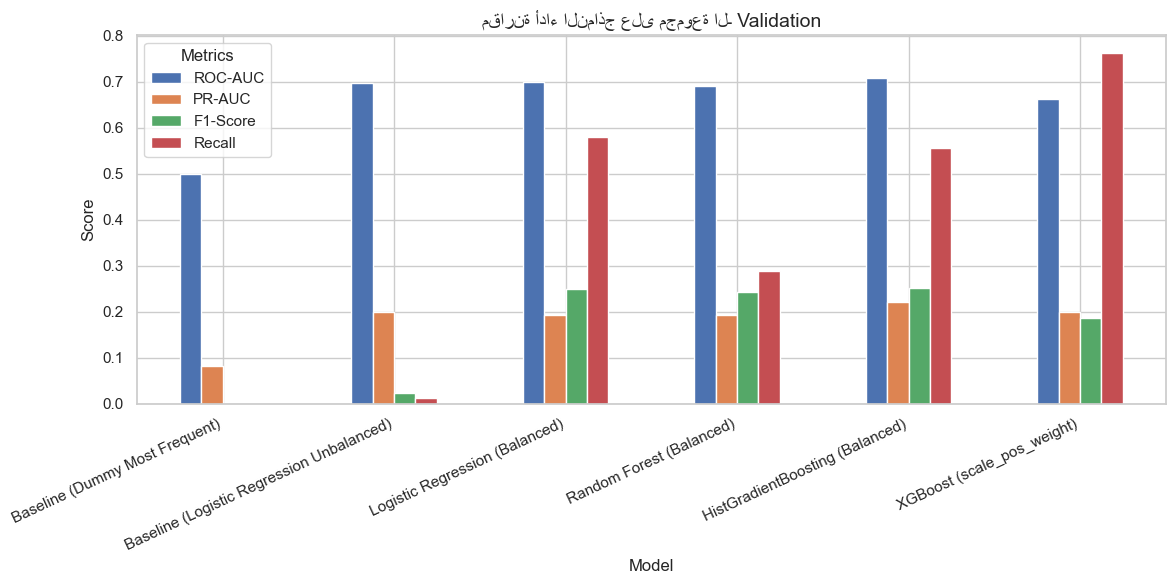

In [ ]:
df_results = pd.DataFrame(results_list)
print("===  جدول مقارنة أداء النماذج على مجموعة الـ Validation ===")
display(df_results)

df_plot = df_results.set_index("Model")[["ROC-AUC", "PR-AUC", "F1-Score", "Recall"]]
df_plot.plot(kind="bar", figsize=(12, 6))
plt.title("مقارنة أداء النماذج على مجموعة الـ Validation", fontsize=14)
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()


## 8️⃣ حفظ الموديل الفائز والـ Artifacts


In [9]:
# تحديد النموذج الفائز بناءً على أعلى ROC-AUC و F1-Score
best_row = df_results.sort_values(by=["ROC-AUC", "F1-Score"], ascending=False).iloc[0]
best_name = best_row["Model"]
best_model = trained_models[best_name]

joblib.dump(best_model, "best_model.pkl")
df_results.to_csv("model_summary.csv", index=False)

print(f"🏆 النموذج الفائز: {best_name}")
print("✅ تم حفظ أفضل موديل بملف: best_model.pkl")
print("✅ تم حفظ ملخص التقييمات بملف: model_summary.csv")


🏆 النموذج الفائز: HistGradientBoosting (Balanced)
✅ تم حفظ أفضل موديل بملف: best_model.pkl
✅ تم حفظ ملخص التقييمات بملف: model_summary.csv


## 9️⃣ التقييم النهائي لمرة واحدة فقط على مجموعة الاختبار (`test.csv`)





🎯 التقرير النهائي للموديل الفائز على مجموعة الاختبار (Test Set)

✅ Test Accuracy: 0.7388
✅ Test ROC-AUC Score: 0.7076
✅ Test PR-AUC Score: 0.2310
✅ Test F1-Score (Class 1): 0.2456
✅ Test Recall (Class 1): 0.5352
✅ Test Precision (Class 1): 0.1594

--- Classification Report ---
              precision    recall  f1-score   support

 On-Time (0)       0.95      0.76      0.84     13013
    Late (1)       0.16      0.54      0.25      1123

    accuracy                           0.74     14136
   macro avg       0.55      0.65      0.54     14136
weighted avg       0.89      0.74      0.79     14136



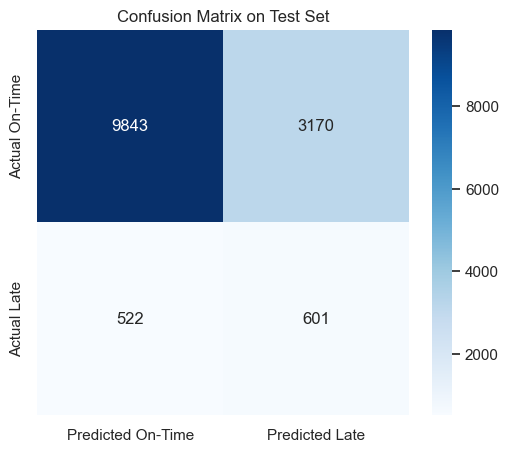

In [10]:
# 1. قراءة ومعالجة بيانات الـ Test بنفس الـ Pipeline
df_test_clean = preprocess_dataset("test.csv", train_cols, scaler)

X_test = df_test_clean.drop(columns=["is_late"])
y_test = df_test_clean["is_late"]

# 2. تحميل الموديل الفائز وتشغيله على الـ Test
loaded_best_model = joblib.load("best_model.pkl")
y_test_pred = loaded_best_model.predict(X_test)
y_test_proba = loaded_best_model.predict_proba(X_test)[:, 1]

# 3. طباعة التقرير النهائي الشامل
print("====================================================")
print("🎯 التقرير النهائي للموديل الفائز على مجموعة الاختبار (Test Set)")
print("====================================================\n")

print(f"✅ Test Accuracy: { (y_test_pred == y_test).mean():.4f}")
print(f"✅ Test ROC-AUC Score: {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"✅ Test PR-AUC Score: {average_precision_score(y_test, y_test_proba):.4f}")
print(f"✅ Test F1-Score (Class 1): {f1_score(y_test, y_test_pred):.4f}")
print(f"✅ Test Recall (Class 1): {recall_score(y_test, y_test_pred):.4f}")
print(f"✅ Test Precision (Class 1): {precision_score(y_test, y_test_pred):.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_test_pred, target_names=["On-Time (0)", "Late (1)"]))

# 4. رسم مصفوفة الالتباس (Confusion Matrix)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted On-Time", "Predicted Late"], yticklabels=["Actual On-Time", "Actual Late"])
plt.title("Confusion Matrix on Test Set")
plt.show()
